### Set up

In [16]:
import torchvision
import torchvision.transforms.v2 as T
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
import torchmetrics
import torch.nn.functional as F

In [17]:
if torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"
device

'cuda'

### Load dataset

In [18]:
toTensor = T.Compose([T.ToImage(), T.ToDtype(torch.float32, scale=True)])

In [19]:
train_and_valid_data = torchvision.datasets.FashionMNIST(root="datasets", train=True, download=True, transform=toTensor)
test_data = torchvision.datasets.FashionMNIST(root="datasets", train=False, download=True, transform=toTensor)

In [20]:
torch.manual_seed(42)
train_data, valid_data = torch.utils.data.random_split(train_and_valid_data, [55_000, 5_000])

In [21]:
batch_size = 256
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=4, prefetch_factor=10, persistent_workers=True, pin_memory=True)
valid_loader = DataLoader(valid_data, batch_size=batch_size, num_workers=4, prefetch_factor=10, persistent_workers=True, pin_memory=True)
test_loader = DataLoader(test_data, batch_size=batch_size, num_workers=4, prefetch_factor=10, persistent_workers=True, pin_memory=True)

### Model - Image Classifier

In [22]:
class ImageClassifier(nn.Module):
    def __init__(self, n_inputs, n_hidden1, n_hidden2, n_classes):
        super().__init__()
        self.mlp = nn.Sequential(nn.Flatten(), nn.Linear(n_inputs, n_hidden1), nn.ReLU(),
                                 nn.Linear(n_hidden1, n_hidden2), nn.ReLU(), nn.Linear(n_hidden2, n_classes))

    def forward(self, X):
        return self.mlp(X)

In [23]:
xentropy = nn.CrossEntropyLoss()
accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=10).to(device)
n_epochs = 100

In [24]:
torch.manual_seed(42)
model = ImageClassifier(n_inputs=28 * 28, n_hidden1=300, n_hidden2=100, n_classes=10).to(device)
model

ImageClassifier(
  (mlp): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=300, bias=True)
    (2): ReLU()
    (3): Linear(in_features=300, out_features=100, bias=True)
    (4): ReLU()
    (5): Linear(in_features=100, out_features=10, bias=True)
  )
)

In [25]:
optimizer = torch.optim.SGD(model.parameters(), lr=0.5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", patience=5, factor=0.5)
metric = torchmetrics.Accuracy(task="multiclass", num_classes=10).to(device)
loss_metric = nn.CrossEntropyLoss()

In [26]:
def evaluate_tm(model, data_loader, metric_fn, aggregate_fn=torch.mean):
    model.eval()
    metrics = []
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            metric = metric_fn(y_pred, y_batch)
            metrics.append(metric)
    return aggregate_fn(torch.stack(metrics))

In [27]:
def train(model, optimizer, criterion, train_loader, valid_loader, n_epochs, verbose=1):
    model.train()
    losses = []
    val_losses = []
    accuracies = []
    val_accuracies = []
    learning_rates = []

    for epoch in range(n_epochs):
        total_loss = 0.
        total_acc = 0.
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            total_loss += loss.item()
            total_acc += accuracy(y_pred, y_batch).item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
        learning_rates.append(scheduler.get_last_lr()[0])
        val_metric = evaluate_tm(model, valid_loader, loss_metric).item()
        scheduler.step(val_metric)
        mean_loss = total_loss / len(train_loader)
        train_accuracy = total_acc / len(train_loader)
        x_val, y_val = next(iter(valid_loader))
        y_val_pred = model(x_val.to(device))
        val_loss = criterion(y_val_pred, y_val.to(device))
        val_acc = accuracy(y_val_pred, y_val.to(device)).item()
        losses.append(mean_loss)
        val_losses.append(val_loss.item())
        accuracies.append(train_accuracy)
        val_accuracies.append(val_acc)
        if verbose:
            print(f"Epoch {epoch + 1}/{n_epochs}, Loss: {mean_loss:.4f}, Validation Loss: {val_loss.item()}, Train Accuracy:         {train_accuracy}, Validation Accuracy: {val_acc}")
    return losses, val_losses, accuracies, val_accuracies, learning_rates

In [28]:
train_loss, val_loss, train_acc, val_acc, lrs = train(model, optimizer, xentropy, train_loader, valid_loader, n_epochs)

Epoch 1/100, Loss: 0.8935, Validation Loss: 0.5783941149711609, Train Accuracy:         0.6699962316557418, Validation Accuracy: 0.8046875
Epoch 2/100, Loss: 0.4990, Validation Loss: 0.6020050048828125, Train Accuracy:         0.8133579620095186, Validation Accuracy: 0.75390625
Epoch 3/100, Loss: 0.4344, Validation Loss: 0.5740039348602295, Train Accuracy:         0.8384245800417524, Validation Accuracy: 0.79296875
Epoch 4/100, Loss: 0.3890, Validation Loss: 0.4727117419242859, Train Accuracy:         0.8551767063695331, Validation Accuracy: 0.81640625
Epoch 5/100, Loss: 0.3633, Validation Loss: 0.4915376901626587, Train Accuracy:         0.864362618535064, Validation Accuracy: 0.80859375
Epoch 6/100, Loss: 0.3447, Validation Loss: 0.4708960950374603, Train Accuracy:         0.8717807925024698, Validation Accuracy: 0.828125
Epoch 7/100, Loss: 0.3362, Validation Loss: 0.40943703055381775, Train Accuracy:         0.8754595983860105, Validation Accuracy: 0.85546875
Epoch 8/100, Loss: 0.31

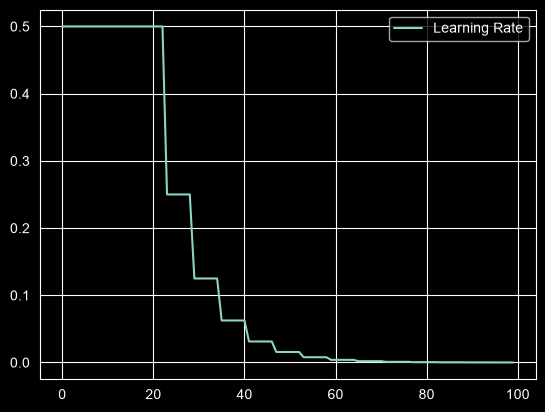

In [29]:
plt.plot(list(range(n_epochs)), lrs, label="Learning Rate")
plt.legend()

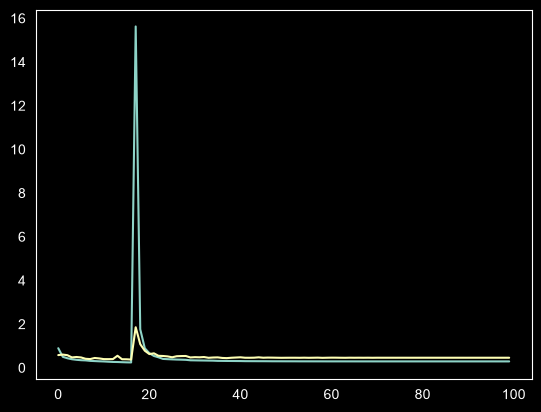

In [30]:
plt.plot(list(range(n_epochs)), train_loss)
plt.plot(list(range(n_epochs)), val_loss)
plt.grid()
plt.show()